<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102329 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102191 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  float64
 12  cancellation_pol

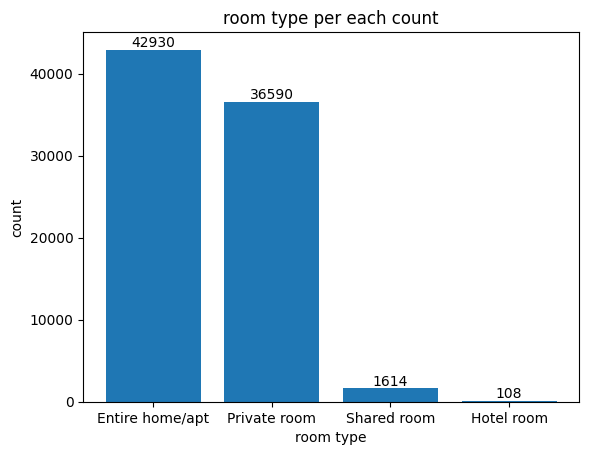

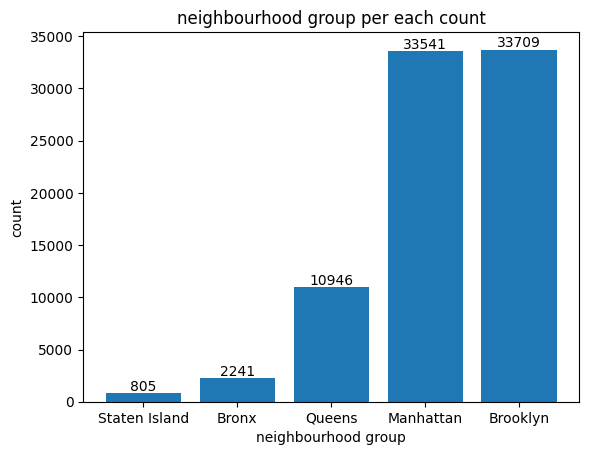

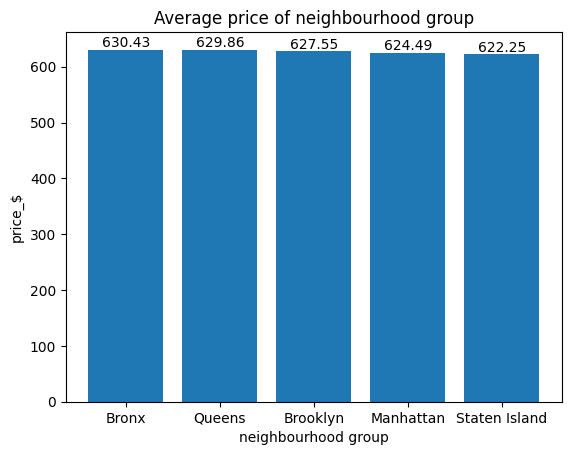

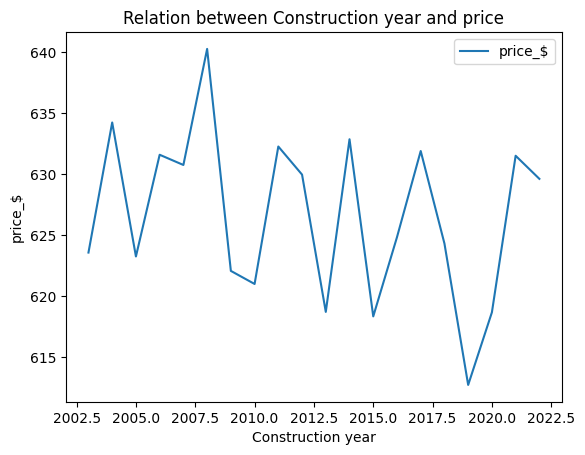

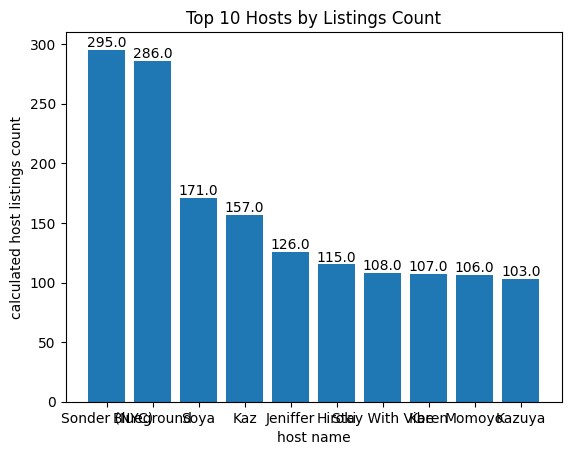

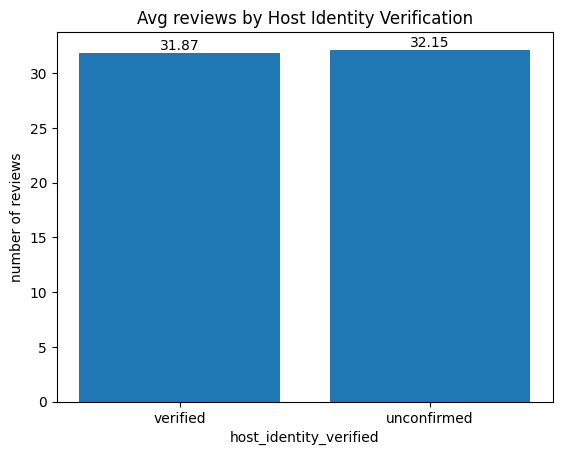

Correlation between price and service fee: 0.9999909005366617


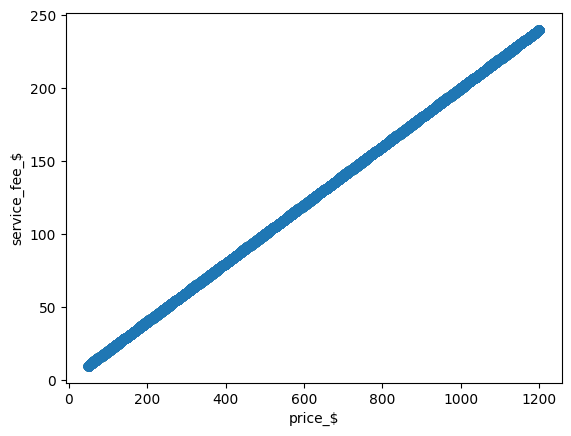

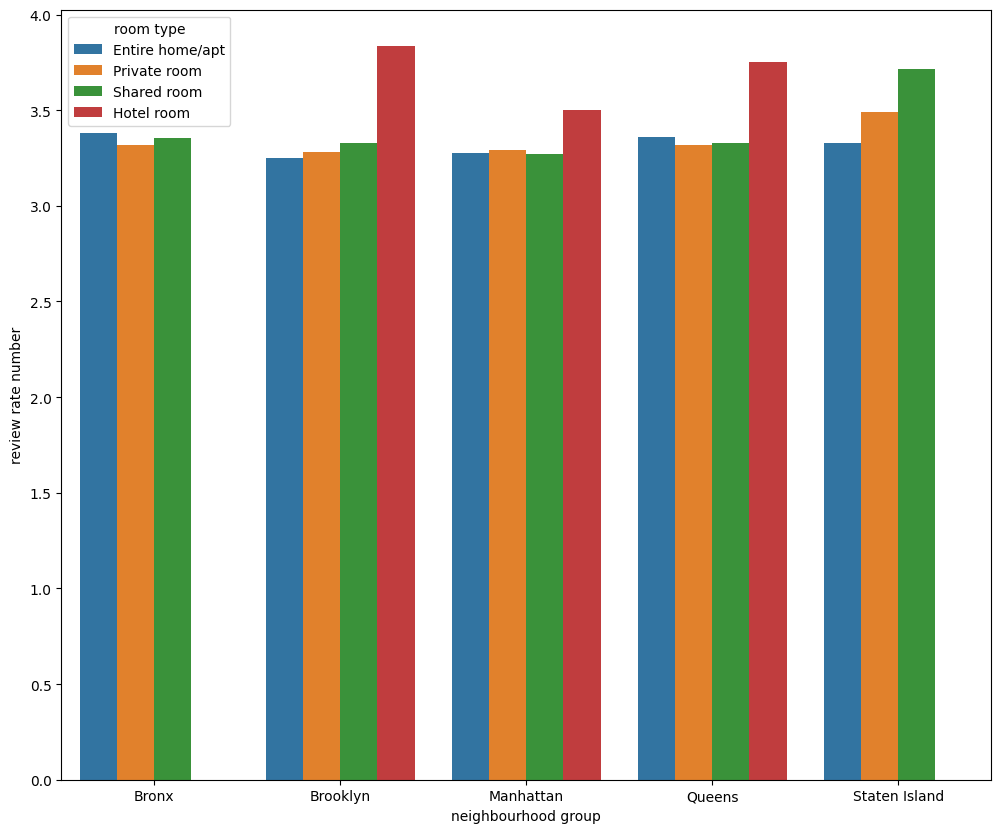

Correlation between listings and availability: 0.14857327574146945


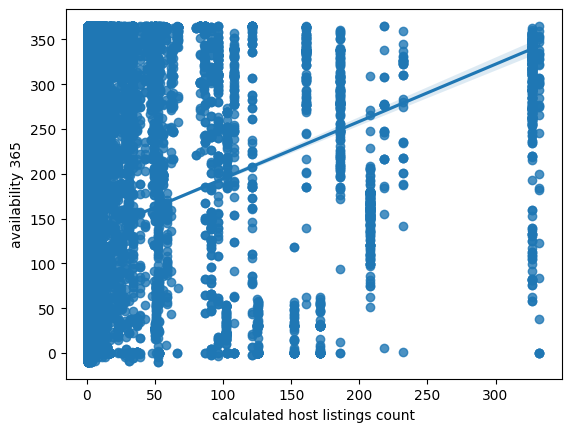

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated read_csv to handle malformed lines
df = pd.read_csv("/content/airbnb_bookings.csv", engine='python', on_bad_lines='skip')

df.head()
df.info()

df = df.drop_duplicates()
df = df.drop(columns=["house_rules", "license"], errors='ignore')

# Clean currency strings
df["price"] = df["price"].replace("$", "")
df["service fee"] = df["service fee"].replace("$","")

df["price"] = df["price"].replace(",", "")
df["service fee"] = df["service fee"].replace(",","")

df.rename(columns={
    "price": "price_$",
    "service fee": "service_fee_$"
}, inplace=True)

df.dropna(inplace=True)

df["price_$"] = df["price_$"].astype(float)
df["service_fee_$"] = df["service_fee_$"].astype(float)
df["id"] = df["id"].astype(str)
df["host id"] = df["host id"].astype(str)
df["last review"] = pd.to_datetime(df["last review"])
df["Construction year"] = df["Construction year"].astype(int)

df.loc[df["neighbourhood group"] == "brookln", "neighbourhood group"] = "Brooklyn"
df = df.drop(df[df["availability 365"] > 365].index)

df.info()

# Visualization 1
room_type = df["room type"].value_counts().to_frame()
room_type_bar = plt.bar(x=room_type.index, height=room_type.loc[:, "count"])
plt.bar_label(room_type_bar, labels=round(room_type.loc[:, "count"]))
plt.xlabel("room type")
plt.ylabel("count")
plt.title("room type per each count")
plt.savefig("room_type_chart.png")
plt.show()

# Visualization 2
hood_group = df["neighbourhood group"].value_counts().sort_values().to_frame()
hood_group_bar = plt.bar(x=hood_group.index, height=hood_group.loc[:, "count"])
plt.bar_label(hood_group_bar, labels=round(hood_group.loc[:, "count"]))
plt.xlabel("neighbourhood group")
plt.ylabel("count")
plt.title("neighbourhood group per each count")
plt.savefig("neighbourhood group_chart.png")
plt.show()

# Visualization 3
avg_price = df.groupby("neighbourhood group")["price_$"].mean().sort_values(ascending=False).to_frame().head(10)
avg_price_bar = plt.bar(x=avg_price.index, height=avg_price.loc[:, "price_$"])
plt.bar_label(avg_price_bar, labels=round(avg_price.loc[:, "price_$"], 2))
plt.xlabel("neighbourhood group")
plt.ylabel("price_$")
plt.title("Average price of neighbourhood group")
plt.savefig("Average price of neighbourhood group_chart.png")
plt.show()

# Visualization 4
df.groupby("Construction year")["price_$"].mean().to_frame().plot()
plt.xlabel("Construction year")
plt.ylabel("price_$")
plt.title("Relation between Construction year and price")
plt.savefig("Relation between Construction year and price_chart.png")
plt.show()

# Visualization 5
hosts = df.groupby("host name")["calculated host listings count"].mean().sort_values(ascending=False).to_frame().head(10)
hosts_bar = plt.bar(x=hosts.index, height=hosts.loc[:, "calculated host listings count"])
plt.bar_label(hosts_bar, labels=round(hosts.loc[:, "calculated host listings count"]))
plt.xlabel("host name")
plt.ylabel("calculated host listings count")
plt.title("Top 10 Hosts by Listings Count")
plt.savefig("Top 10 Hosts by Listings Count_chart.png")
plt.show()

# Visualization 6
review = df.groupby("host_identity_verified")["number of reviews"].mean().sort_values().to_frame()
review_bar = plt.bar(x=review.index, height=review.loc[:, "number of reviews"])
plt.bar_label(review_bar, labels=round(review.loc[:, "number of reviews"], 2))
plt.xlabel("host_identity_verified")
plt.ylabel("number of reviews")
plt.title("Avg reviews by Host Identity Verification")
plt.savefig("Avg reviews by Host Identity Verification_chart.png")
plt.show()

# Regression plots
print(f"Correlation between price and service fee: {df['price_$'].corr(df['service_fee_$'])}")
sns.regplot(data=df, x="price_$", y="service_fee_$")
plt.savefig("Correlation between price and service fee_chart.png")
plt.show()

ARRN = df.groupby(["neighbourhood group", "room type"])["review rate number"].mean().reset_index()
plt.figure(figsize=(12, 10))
sns.barplot(data=ARRN, x="neighbourhood group", y="review rate number", hue="room type")
plt.savefig("review_rate_by_neighbourhood_roomtype.png_chart.png")
plt.show()

print(f"Correlation between listings and availability: {df['calculated host listings count'].corr(df['availability 365'])}")
sns.regplot(data=df, x="calculated host listings count", y="availability 365")
plt.savefig("Correlation between listings and availability_chart.png")
plt.show()